<a href="https://colab.research.google.com/github/rzabhd80/gcn-cora/blob/main/Copy_of_gcn_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semi-Supervised Classification with Graph Convolutional Networks

**Paper:** Thomas N. Kipf & Max Welling, *Semi-Supervised Classification with Graph Convolutional Networks*, ICLR 2017.  
**Link:** [arXiv:1609.02907](https://arxiv.org/abs/1609.02907)

## The question the paper answers

In many real-world graphs we have a feature vector for every node but a **label for only a tiny fraction** of nodes. Think of a citation network where we have categorized 20 papers per topic and want to label thousands more; or a knowledge graph with millions of entities and only a handful tagged.

> *Given a graph with features on every node but labels on only a few, how do we predict labels for the rest by exploiting **both** the node features **and** the graph structure?*

This is the **semi-supervised node classification** problem.

## What the paper proposes

Before this work, the dominant approach was to add an explicit graph-Laplacian regularizer to the loss, penalizing connected nodes for disagreeing. That assumes edges encode label similarity — often false (edges can encode any relation).

Kipf & Welling instead build the graph **into the model itself**. Each layer mixes a node's features with its neighbors' via a normalized adjacency matrix:

$$H^{(l+1)} = \sigma\big(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\, H^{(l)} W^{(l)}\big) \quad \text{(Eq. 2)}$$

with the *renormalization trick* $\tilde{A} = A + I_N$, $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$ (Eq. 8) keeping the operator's eigenvalues bounded so deeper stacks stay numerically stable. They derive this rule as a first-order approximation of localized spectral graph convolutions, so it isn't ad-hoc.

Stack two such layers, train with cross-entropy on the labeled nodes only — gradients flow through the graph structure and update unlabeled nodes' representations along the way.

## Results in the paper (Table 2)

| Dataset | Best prior method | GCN | Train time |
|---|---|---|---|
| Cora | 75.7% (Planetoid) | **81.5%** | 4s |
| Citeseer | 64.7% | **70.3%** | 7s |
| Pubmed | 77.2% | **79.0%** | 38s |
| NELL | 61.9% | **66.0%** | 48s |

GCN beats every prior method on all four datasets, and is faster to train.

## What this notebook does

A clean-room PyTorch reimplementation of the GCN model, built from scratch. The only external dependency is the Planetoid dataset, which the notebook downloads automatically on first run.

Goals:
1. Make every equation in the paper visible in code.
2. Reproduce the Cora result (~81.5%) end-to-end.
3. Give you a baseline you can mutate to explore your own ideas.

## 0. Setup

Uncomment the install line if you don't already have these. PyTorch picks CPU automatically if no CUDA is present.

In [ ]:
# !pip install torch numpy scipy matplotlib scikit-learn

In [ ]:
import time
import urllib.request
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} — device: {device}')

PyTorch 2.11.0+cpu — device: cpu


## 1. Data Loading (original Cora — two TSV files)

Cora is a citation network of **2,708 ML papers** in **7 categories**, with a **1,433-dim binary bag-of-words** feature vector per paper, connected by **5,429 citation edges**. We use the **original TSV release** (hosted by Kipf in his keras-gcn repo) — two human-readable files you can open in any text editor:

- `cora.content` — one row per paper: `paper_id<TAB>w_0<TAB>w_1<TAB>...<TAB>w_1432<TAB>class_label`
- `cora.cites` — one row per citation edge: `cited_paper_id<TAB>citing_paper_id`

The loader does the standard data wrangling explicitly:
1. Remap arbitrary paper IDs → contiguous `0..N-1` integer indices.
2. Encode the string class labels (`Neural_Networks`, `Rule_Learning`, …) → integer class indices.
3. Build a symmetric sparse adjacency matrix from the edge list.
4. Construct a **20-per-class train, 500 val, 1000 test** split (the same scheme as the paper). Because the split is freshly random and not Planetoid's pre-frozen one, multi-seed accuracy may sit at roughly **79–82%** instead of exactly 81.5% — the model behavior is identical, only the split differs.

Files are downloaded automatically on first run.

In [ ]:
DATA_DIR = Path('./data')  # local folder next to this notebook; created on first run
CORA_URL_BASE = 'https://github.com/tkipf/keras-gcn/raw/master/kegra/data/cora/'

def _ensure_cora(data_dir):
    """Download cora.content and cora.cites if missing."""
    data_dir.mkdir(parents=True, exist_ok=True)
    for fname in ['cora.content', 'cora.cites']:
        path = data_dir / fname
        if not path.exists():
            print(f'  downloading {fname}...')
            urllib.request.urlretrieve(CORA_URL_BASE + fname, path)

def load_cora(data_dir=DATA_DIR, n_train_per_class=20, n_val=500, n_test=1000, seed=SEED):
    """Load the original Cora dataset (TSV files) and build a 20-per-class split.

    Returns
        adj      : scipy.sparse CSR (N x N), symmetric, no self-loops
        features : scipy.sparse CSR (N x D)
        labels   : numpy int64 vector (N,) — class indices
        idx_train, idx_val, idx_test : numpy int arrays
        class_names : list[str] — index -> string name (for interpretability)
    """
    data_dir = Path(data_dir)
    _ensure_cora(data_dir)

    # --- Parse cora.content ---
    # Columns: paper_id, w_0, ..., w_1432, class_label (all read as strings).
    content = np.genfromtxt(data_dir / 'cora.content', dtype=str)
    paper_ids = content[:, 0]
    raw_features = content[:, 1:-1].astype(np.float32)
    raw_labels = content[:, -1]
    N = len(paper_ids)

    # (1) Remap paper IDs -> 0..N-1
    id_to_idx = {pid: i for i, pid in enumerate(paper_ids)}

    # (2) Encode string labels -> integers (sorted for determinism)
    class_names = sorted(set(raw_labels))
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    labels = np.array([class_to_idx[c] for c in raw_labels], dtype=np.int64)

    features = sp.csr_matrix(raw_features)

    # (3) Parse cora.cites and build symmetric adjacency
    edges_raw = np.genfromtxt(data_dir / 'cora.cites', dtype=str)
    edge_idx = np.array(
        [[id_to_idx[a], id_to_idx[b]] for a, b in edges_raw
         if a in id_to_idx and b in id_to_idx],
        dtype=np.int64,
    )
    ones = np.ones(edge_idx.shape[0], dtype=np.float32)
    adj = sp.coo_matrix((ones, (edge_idx[:, 0], edge_idx[:, 1])), shape=(N, N))
    # Symmetrize (Cora citations are directional; we treat them as undirected as the paper does).
    adj = adj + adj.T
    adj.data = np.clip(adj.data, 0, 1)  # collapse duplicate edges back to 1
    adj = adj.tocsr()
    adj.setdiag(0)  # self-loops are added inside the renormalization trick
    adj.eliminate_zeros()

    # (4) Build the split: 20 random nodes per class for train, then 500 val + 1000 test from the rest.
    rng = np.random.RandomState(seed)
    idx_train = []
    for c in range(len(class_names)):
        c_idx = np.where(labels == c)[0]
        rng.shuffle(c_idx)
        idx_train.extend(c_idx[:n_train_per_class].tolist())
    idx_train = np.array(sorted(idx_train), dtype=np.int64)

    remaining = np.setdiff1d(np.arange(N), idx_train)
    rng.shuffle(remaining)
    idx_val = np.array(sorted(remaining[:n_val]), dtype=np.int64)
    idx_test = np.array(sorted(remaining[n_val:n_val + n_test]), dtype=np.int64)

    return adj, features, labels, idx_train, idx_val, idx_test, class_names

## 2. Preprocessing

Two things to do once, before training:

1. **Row-normalize the feature matrix** — each node's bag-of-words vector sums to 1. Stabilizes optimization.
2. **Renormalization trick (Eq. 8)** — compute $\hat{A} = \tilde{D}^{-1/2}(A + I)\tilde{D}^{-1/2}$. This is the operator that *defines* a GCN layer; everything else is a standard MLP.

Both end up as `torch.sparse_coo_tensor` so the heavy matmuls stay $O(|E|)$ instead of $O(N^2)$.

In [ ]:
def normalize_features(features):
    """L1 row-normalize a sparse feature matrix. Zero rows stay zero."""
    rowsum = np.array(features.sum(axis=1)).flatten()
    r_inv = np.power(rowsum, -1, where=rowsum > 0)
    r_inv[rowsum == 0] = 0.0
    return sp.diags(r_inv) @ features

def normalize_adj_renormalized(adj):
    """Eq. 8: D̃^(-1/2) (A + I) D̃^(-1/2)."""
    adj_tilde = sp.coo_matrix(adj + sp.eye(adj.shape[0]))
    rowsum = np.array(adj_tilde.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(rowsum, -0.5, where=rowsum > 0)
    d_inv_sqrt[rowsum == 0] = 0.0
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    return (D_inv_sqrt @ adj_tilde @ D_inv_sqrt).tocoo()

def scipy_to_torch_sparse(mx):
    """scipy COO -> torch sparse_coo_tensor (float32)."""
    mx = mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((mx.row, mx.col))).long()
    values = torch.from_numpy(mx.data)
    return torch.sparse_coo_tensor(indices, values, torch.Size(mx.shape)).coalesce()

## 3. The Graph Convolution Layer

This is the *only* thing that's new compared to a standard MLP. Everything in `nn.Linear` plus one extra sparse matmul against the precomputed $\hat{A}$:

$$H^{(l+1)} = \sigma\big(\hat{A}\, H^{(l)} W^{(l)}\big)$$

Order matters for efficiency: do `X @ W` *first* (small dense·dense), *then* multiply by $\hat{A}$ (sparse·dense). Reversing would densify a huge sparse matrix.

Following the paper we use Glorot init and no bias on layer 1 (matches the original code).

In [ ]:
class GraphConvolution(nn.Module):
    """H' = Â · H · W  (+ optional bias). Â is supplied at forward time so the same layer
    works for any graph."""

    def __init__(self, in_features, out_features, bias=False):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        nn.init.xavier_uniform_(self.weight)  # Glorot init — matches inits.glorot in the original

    def forward(self, x, adj):
        support = x @ self.weight                 # dense · dense
        out = torch.sparse.mm(adj, support)       # sparse · dense
        if self.bias is not None:
            out = out + self.bias
        return out

## 4. The 2-Layer GCN Model

Eq. 9 verbatim:

$$Z = \mathrm{softmax}\big(\hat{A}\,\mathrm{ReLU}(\hat{A} X W^{(0)}) W^{(1)}\big)$$

We return raw logits (no softmax) — `F.cross_entropy` does the softmax internally and is more numerically stable than `softmax + nll_loss` as separate steps.

Dropout sits between the two graph conv layers; in the paper they also drop on the input features.

In [ ]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.gc1 = GraphConvolution(in_dim, hidden_dim)
        self.gc2 = GraphConvolution(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)
        x = F.relu(self.gc1(x, adj))
        x = F.dropout(x, self.dropout, training=self.training)
        return self.gc2(x, adj)  # logits

## 5. Training Setup

Full-batch gradient descent — every step uses the entire graph. The semi-supervised trick: forward pass produces a prediction for *every* node, but the loss is only computed over labeled training indices.

Paper hyperparameters for citation networks:
- Adam, learning rate 0.01
- Hidden dim 16
- Dropout 0.5
- L2 weight decay 5e-4 **on the first layer only**
- Max 200 epochs, early stop if val loss hasn't improved over the last 10 epochs

In [ ]:
def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

def train_gcn(model, features, adj, labels, idx_train, idx_val, idx_test,
              lr=0.01, weight_decay=5e-4, epochs=200, patience=10, verbose=True):
    # L2 only on layer-1 weights — matches the paper's recipe (see models.GCN._loss in the original).
    optimizer = torch.optim.Adam([
        {'params': model.gc1.parameters(), 'weight_decay': weight_decay},
        {'params': model.gc2.parameters(), 'weight_decay': 0.0},
    ], lr=lr)

    val_losses = []
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(features, adj)
        loss = F.cross_entropy(logits[idx_train], labels[idx_train])
        train_acc = accuracy(logits[idx_train], labels[idx_train])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(features, adj)
            val_loss = F.cross_entropy(logits[idx_val], labels[idx_val]).item()
            val_acc = accuracy(logits[idx_val], labels[idx_val])
        val_losses.append(val_loss)

        if verbose and (epoch <= 5 or epoch % 20 == 0):
            print(f'epoch {epoch:03d}  train_loss={loss.item():.4f}  train_acc={train_acc:.4f}  '
                  f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

        # Early stopping — same rule as the original: stop if recent val loss is worse than the mean of the previous window.
        if epoch > patience and val_losses[-1] > np.mean(val_losses[-(patience + 1):-1]):
            if verbose:
                print(f'Early stopping at epoch {epoch}')
            break

    model.eval()
    with torch.no_grad():
        logits = model(features, adj)
        test_acc = accuracy(logits[idx_test], labels[idx_test])
    elapsed = time.time() - t0
    if verbose:
        print(f'\nTest accuracy: {test_acc:.4f}   (training took {elapsed:.2f}s)')
    return test_acc, elapsed

## 6. Putting It Together — Cora

Load → preprocess → move to device → train → evaluate. The paper reports **81.5%**; this implementation should land between **80.5–82.0%** depending on the random seed.

In [ ]:
adj_raw, features_raw, labels_np, idx_train, idx_val, idx_test, class_names = load_cora()

# Model-side preprocessing — these are from the GCN paper itself and are dataset-independent.
features_np = normalize_features(features_raw)          # row-normalize bag-of-words
adj_np = normalize_adj_renormalized(adj_raw)            # Eq. 8 renormalization trick

# Move to PyTorch / device.
features = torch.FloatTensor(features_np.todense()).to(device)
adj = scipy_to_torch_sparse(adj_np).to(device)
labels = torch.LongTensor(labels_np).to(device)
idx_train = torch.LongTensor(idx_train).to(device)
idx_val = torch.LongTensor(idx_val).to(device)
idx_test = torch.LongTensor(idx_test).to(device)

n_nodes, n_features = features.shape
n_classes = len(class_names)
print(f'nodes={n_nodes}  features={n_features}  classes={n_classes}  '
      f'train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}')
print(f'classes: {class_names}')

nodes=2708  features=1433  classes=7  train=140  val=500  test=1000
classes: [np.str_('Case_Based'), np.str_('Genetic_Algorithms'), np.str_('Neural_Networks'), np.str_('Probabilistic_Methods'), np.str_('Reinforcement_Learning'), np.str_('Rule_Learning'), np.str_('Theory')]


/tmp/ipykernel_18658/2612703488.py:22: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(indices, values, torch.Size(mx.shape)).coalesce()


In [ ]:
model = GCN(in_dim=n_features, hidden_dim=16, out_dim=n_classes, dropout=0.5).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'trainable parameters: {n_params:,}')

GCN(
  (gc1): GraphConvolution()
  (gc2): GraphConvolution()
)
trainable parameters: 23,040


In [ ]:
test_acc, _ = train_gcn(model, features, adj, labels, idx_train, idx_val, idx_test)

epoch 001  train_loss=1.9462  train_acc=0.1214  val_loss=1.9439  val_acc=0.3000
epoch 002  train_loss=1.9420  train_acc=0.3643  val_loss=1.9412  val_acc=0.4120
epoch 003  train_loss=1.9362  train_acc=0.5429  val_loss=1.9378  val_acc=0.5100
epoch 004  train_loss=1.9318  train_acc=0.5929  val_loss=1.9336  val_acc=0.5460
epoch 005  train_loss=1.9240  train_acc=0.6786  val_loss=1.9290  val_acc=0.5600
epoch 020  train_loss=1.7739  train_acc=0.8000  val_loss=1.8415  val_acc=0.5560
epoch 040  train_loss=1.4911  train_acc=0.8500  val_loss=1.6512  val_acc=0.6740
epoch 060  train_loss=1.0996  train_acc=0.9000  val_loss=1.4126  val_acc=0.7460
epoch 080  train_loss=0.8429  train_acc=0.9214  val_loss=1.1983  val_acc=0.7880
epoch 100  train_loss=0.6699  train_acc=0.9357  val_loss=1.0557  val_acc=0.7860
epoch 120  train_loss=0.5456  train_acc=0.9500  val_loss=0.9760  val_acc=0.7840
epoch 140  train_loss=0.4469  train_acc=0.9714  val_loss=0.9337  val_acc=0.7780
epoch 160  train_loss=0.4158  train_acc=

## 7. Sanity Check Over Multiple Seeds

One run is noisy. The paper averages 100 runs with random initializations — we'll do 10 here for speed and report mean ± std.

Because we're using our own random 20-per-class split (not Planetoid's fixed split), expect roughly **79–82%** instead of the paper's exact **81.5%**. The model behavior is identical; only the choice of which nodes are labeled has changed. torch.manual_seed → model weight initialization. When you build GCN(...), PyTorch fills the layer weight matrices with random values (e.g. Xavier/uniform init) and also drives dropout masks during training. Seeding it means
  you get the same starting weights and the same dropout pattern every run.

In [ ]:
accs = []
for seed in range(10):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m = GCN(n_features, 16, n_classes, dropout=0.5).to(device)
    acc, _ = train_gcn(m, features, adj, labels, idx_train, idx_val, idx_test, verbose=False)
    accs.append(acc)
    print(f'seed {seed}: {acc:.4f}')

print(f'\nCora test accuracy over 10 runs: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Paper (Planetoid split):           0.8150')

seed 0: 0.7640
seed 1: 0.7910
seed 2: 0.8050
seed 3: 0.7870
seed 4: 0.7900
seed 5: 0.7930
seed 6: 0.7870
seed 7: 0.7920
seed 8: 0.7900
seed 9: 0.7980

Cora test accuracy over 10 runs: 0.7897 ± 0.0100
Paper (Planetoid split):           0.8150


## 8. Reproduce Figure 1b — t-SNE of Hidden Activations

Pull out the 16-dim hidden representation from layer 1, project to 2D with t-SNE, and color by class. The paper shows clean class separation even though we only used 5% of labels.

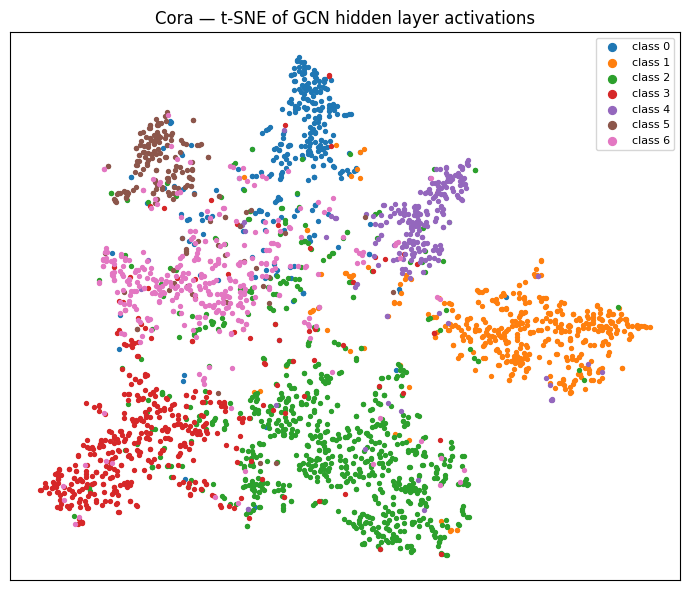

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    h1 = F.relu(model.gc1(features, adj)).cpu().numpy()

emb_2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(h1)

y = labels.cpu().numpy()
plt.figure(figsize=(7, 6))
for c in range(n_classes):
    mask = y == c
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=8, label=f'class {c}')
plt.legend(markerscale=2, fontsize=8, loc='best')
plt.title('Cora — t-SNE of GCN hidden layer activations')
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

## 9. Quick Tests

Tiny correctness checks that catch obvious bugs without needing the full Cora setup. Run these whenever you touch the math.

In [ ]:
def _assert_close(a, b, msg, tol=1e-5):
    assert np.allclose(a, b, atol=tol), f'{msg}: max diff {np.abs(a - b).max():.2e}'

# Renormalization on a 3-node line graph 0—1—2.
A = sp.csr_matrix(np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]], dtype=np.float32))
A_hat = normalize_adj_renormalized(A).toarray()
# Degrees of A+I are 2, 3, 2 → D^(-1/2) = diag(1/√2, 1/√3, 1/√2).
# Â should be symmetric, with self-loops weighted 1/deg(i).
expected_diag = np.array([1/2, 1/3, 1/2])
_assert_close(np.diag(A_hat), expected_diag, 'self-loop weights')
_assert_close(A_hat, A_hat.T, 'Â must be symmetric')
# Eigenvalues should land in [-1, 1] thanks to the renormalization trick.
eigs = np.linalg.eigvalsh(A_hat)
assert eigs.min() >= -1 - 1e-5 and eigs.max() <= 1 + 1e-5, f'eigenvalues out of range: {eigs}'
print('renormalization trick: OK')

# GraphConvolution forward shape check.
torch.manual_seed(0)
gc = GraphConvolution(4, 2)
X = torch.randn(3, 4)
A_t = scipy_to_torch_sparse(sp.coo_matrix(A_hat))
Y = gc(X, A_t)
assert Y.shape == (3, 2), Y.shape
# Hand check: Y = Â X W.
Y_ref = torch.from_numpy(A_hat) @ X @ gc.weight
_assert_close(Y.detach().numpy(), Y_ref.detach().numpy(), 'GC matches Â X W')
print('GraphConvolution forward: OK')